# CS324 Assignment 1

**学号：12411103**

本 Notebook 覆盖 Part I、II、III。代码全部使用 NumPy 手工计算梯度；scikit-learn 仅生成双月数据和进行随机划分。图中 train/test 均为完整数据集评估。

默认读取随提交提供的真实实验记录，便于快速查看。把下一单元的 `RECOMPUTE = True` 后运行全部单元，会从头执行报告中的所有实验并更新图表。也可以先运行 `python run_experiments.py`。

In [1]:
from pathlib import Path
import json
import numpy as np
from IPython.display import Image, Markdown, display
from run_experiments import run_all
ROOT = Path.cwd()
assert (ROOT / "run_experiments.py").exists(), "Open the notebook from its own directory"
RECOMPUTE = False
if RECOMPUTE or not (ROOT / "results/metadata.json").exists():
    run_all()
results = ROOT / "results"
part1 = json.loads((results / "part1_results.json").read_text(encoding="utf-8"))
mlp = json.loads((results / "mlp_results.json").read_text(encoding="utf-8"))
metadata = json.loads((results / "metadata.json").read_text(encoding="utf-8"))
def figure(name):
    display(Image(filename=str(results / "figures" / name)))
def table(headers, rows):
    display(Markdown("| " + " | ".join(headers) + " |\n| " + " | ".join(["---"]*len(headers)) + " |\n" +
                     "\n".join("| " + " | ".join(map(str, row)) + " |" for row in rows)))
print("Recorded environment:", metadata["python"].split()[0], "NumPy", metadata["numpy"], "sklearn", metadata["scikit_learn"])

Recorded environment: 3.14.6 NumPy 2.5.3 sklearn 1.9.0


## Part I：感知机

### Task 1：生成数据
两类分布为 $N((-2,-2),I)$、$N((2,2),I)$。每类独立采样100点，打乱后分别取80点训练、20点测试；标签为 -1/+1，随机种子42。

In [2]:
from Part_1.task1_dataset import generate_gaussian_dataset
from Part_1.perceptron import Perceptron
X_train, y_train, X_test, y_test = generate_gaussian_dataset(seed=42)
print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print("Train counts:", np.unique(y_train, return_counts=True))
print("Test counts:", np.unique(y_test, return_counts=True))

Shapes: (160, 2) (160,) (40, 2) (40,)
Train counts: (array([-1,  1]), array([80, 80]))
Test counts: (array([-1,  1]), array([20, 20]))


### Task 2、3：整批更新与测试
模型为 $\hat y=\mathrm{sign}(w^Tx+b)$，零分数归为 +1。令 $M$ 为当前误分类样本集合，使用增广输入 $\tilde x=(x_1,x_2,1)$，每轮执行 $\tilde w\leftarrow\tilde w+\eta |M|^{-1}\sum_{i\in M}y_i\tilde x_i$。若无误分类则停止，否则最多100轮，学习率0.01。

In [3]:
model = Perceptron(2, max_epochs=100, learning_rate=0.01).train(X_train, y_train)
print("Weights [w1,w2,b]:", model.weights)
print("Epochs checked:", len(model.errors_per_epoch))
print("Train accuracy: %.2f%%" % (100*np.mean(model.forward(X_train)==y_train)))
print("Test accuracy: %.2f%%" % (100*np.mean(model.forward(X_test)==y_test)))

Weights [w1,w2,b]: [ 0.0424473   0.02111334 -0.02      ]
Epochs checked: 49
Train accuracy: 100.00%
Test accuracy: 100.00%


### Task 4：均值距离与方差
控制变量：每坐标均值差从4减为1，或方差从1增为9；同时改变二者作为第四种条件。每种条件使用42至51共10个种子。下面的标准差是样本标准差（ddof=1），不是置信区间。

| Condition | Train % (42) | Test % (42) | Test % mean +/- SD | Converged / 10 |
| --- | --- | --- | --- | --- |
| Separated | 100.00 | 100.00 | 99.50 +/- 1.05 | 10 |
| Close means | 62.50 | 60.00 | 66.75 +/- 8.66 | 0 |
| High variance | 72.50 | 67.50 | 75.00 +/- 8.74 | 0 |
| Close + high variance | 58.75 | 65.00 | 50.25 +/- 9.31 | 0 |

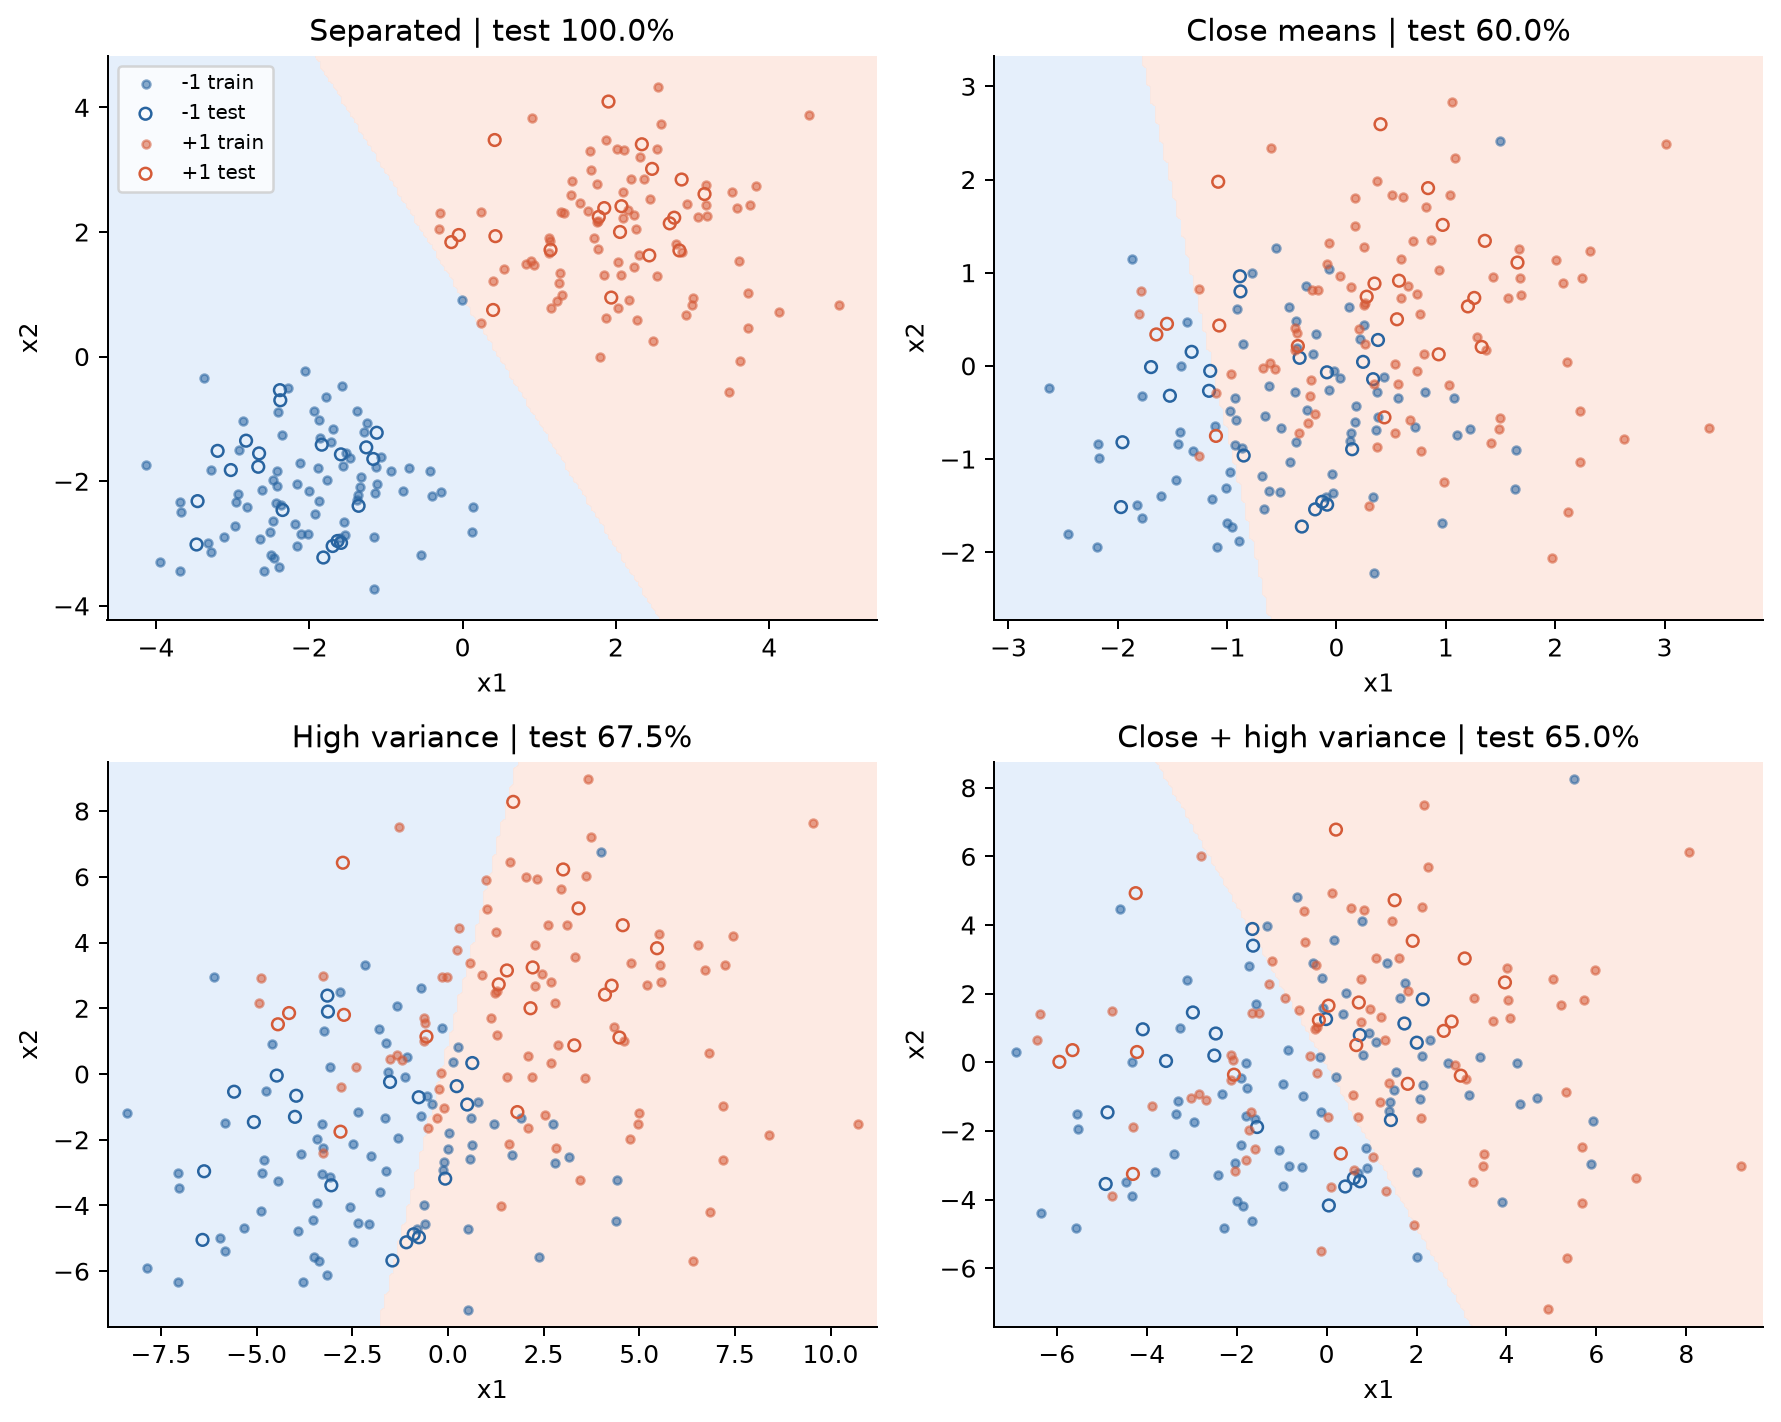

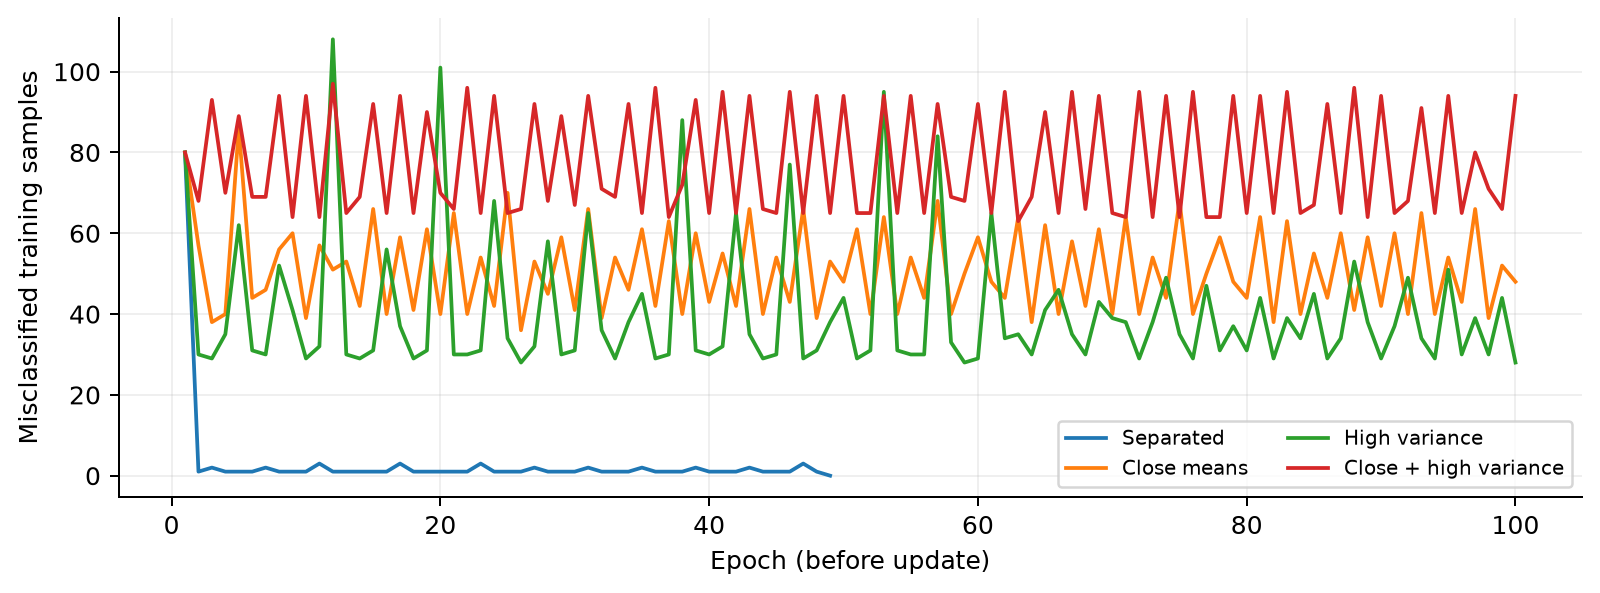

In [4]:
rows = []
for case in part1:
    values = [r["test_accuracy"] for r in case["runs"]]
    r = case["runs"][0]
    rows.append([case["name"], format(r["train_accuracy"], ".2f"), format(r["test_accuracy"], ".2f"),
                 f"{np.mean(values):.2f} +/- {np.std(values, ddof=1):.2f}",
                 sum(v["converged"] for v in case["runs"])])
table(["Condition", "Train % (42)", "Test % (42)", "Test % mean +/- SD", "Converged / 10"], rows)
figure("part1_boundaries.png")
figure("part1_errors.png")

均值接近或方差增大使两类重叠，100轮内可能持续出现误分类和振荡。高斯分布本身具有无界支撑；即使总体有重叠，一次有限采样也可能线性可分。不收敛仅表示此运行未达到零训练误差，不是不可分性的形式证明。重叠也存在不可约分类误差，换用非线性模型并不保证全部正确。

## Part II：NumPy MLP

默认结构为 `2 → 20 (ReLU) → 2 (Softmax)`。权重采样自 N(0, 0.1²)，偏置为0。均值交叉熵配合融合梯度 `(probabilities - targets) / batch_size`；`MLP.backward` 接收 logits 梯度，跳过重复 Softmax 求导。

1000个双月点随机分为800训练、200测试（分层随机划分）。噪声0，无标准化。固定学习率0.01、1500个完整epoch、每10轮评估一次；初始化时额外评估epoch 0。

Shapes: [(800, 2), (800, 2), (200, 2), (200, 2)]
Class counts: [400. 400.] [100. 100.]


| epoch | updates | train loss | test loss | train % | test % |
| --- | --- | --- | --- | --- | --- |
| 0 | 0 | 0.69714 | 0.69716 | 50.0 | 50.0 |
| 1500 | 1500 | 0.28431 | 0.25450 | 86.125 | 89.0 |

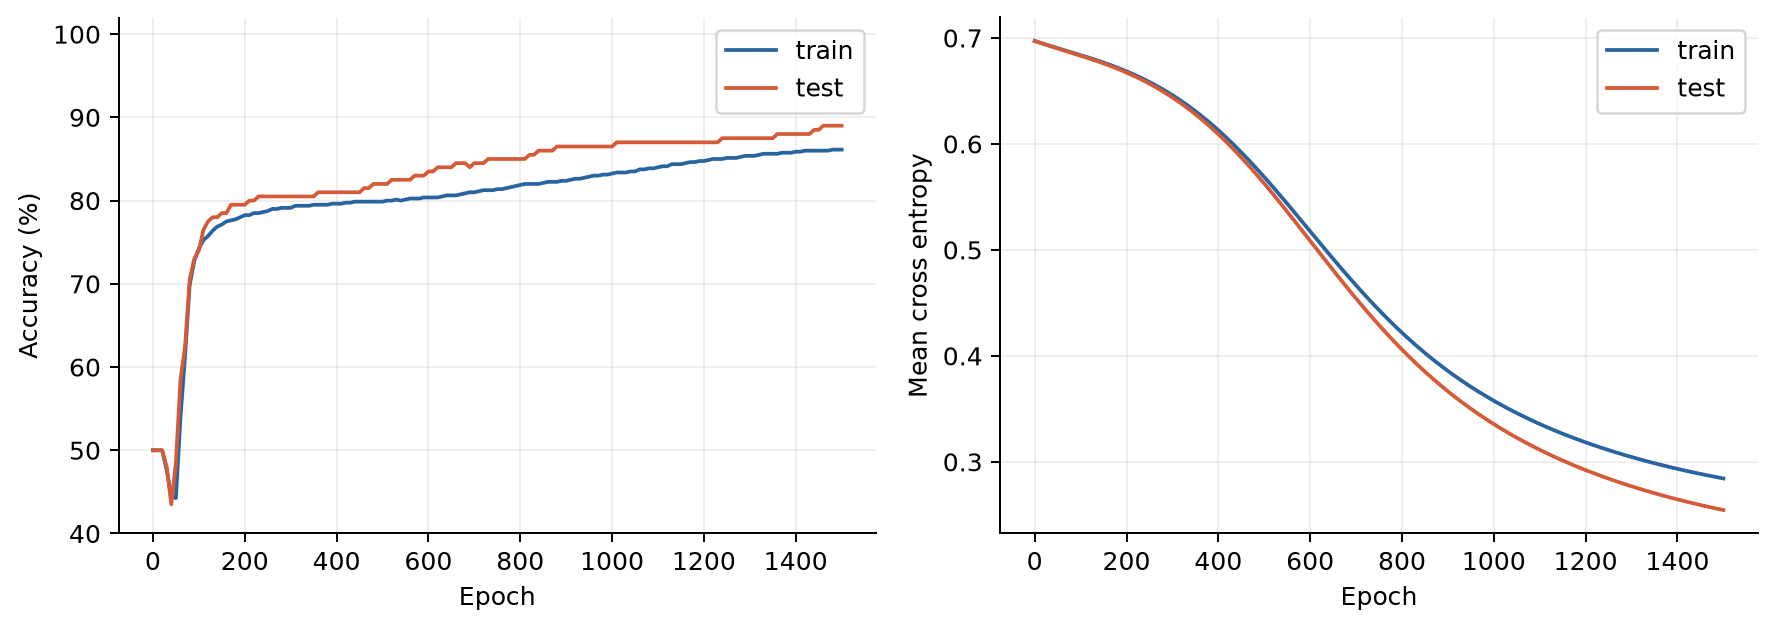

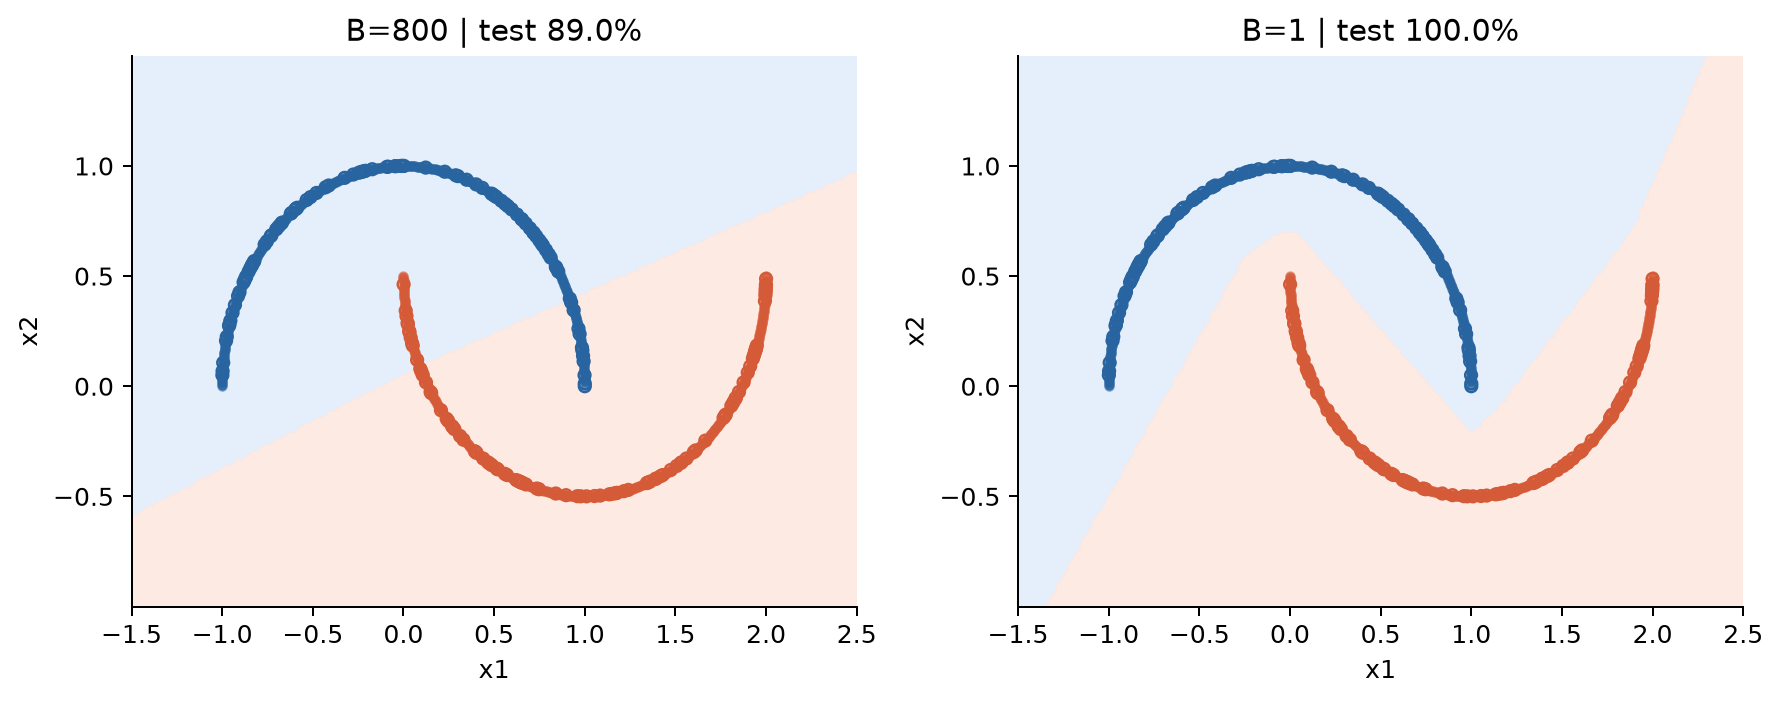

In [5]:
from Part_2.train_mlp_numpy import make_dataset, train
data = make_dataset(seed=42)
print("Shapes:", [a.shape for a in data])
print("Class counts:", data[1].sum(axis=0), data[3].sum(axis=0))
# To run this baseline independently:
# model, history, data = train(batch_size=800, seed=42)
full = next(r for r in mlp if r["seed"] == 42 and r["batch_size"] == 800)
table(["epoch", "updates", "train loss", "test loss", "train %", "test %"],
      [[h["epoch"],h["updates"],format(h["train_loss"], ".5f"),format(h["test_loss"], ".5f"),
        h["train_accuracy"],h["test_accuracy"]] for h in [full["history"][0], full["history"][-1]]])
figure("part2_full_batch.png")
figure("mlp_boundaries.png")

左侧决策区域来自全批量模型，右侧来自SGD模型。默认1500轮的全批量结果如实保留，不使用测试集选择最优轮次或调整参数。训练、测试曲线接近仅说明在此划分下差距小，不能证明没有过拟合或已经达到全局最优。

## Part III：SGD与batch size

传入 `batch_size=1` 为SGD，`800`为全批量，中间值为小批量。每轮重新打乱训练集，末尾不足一个批次的样本仍会更新，并按实际批次长度求平均。

SGD final metrics: {'epoch': 1500, 'updates': 1200000, 'elapsed_seconds': 44.07332349999342, 'train_loss': 7.474669757212858e-05, 'test_loss': 8.06477577290803e-05, 'train_accuracy': 100.0, 'test_accuracy': 100.0}
Confusion matrix (rows=true, columns=predicted): [[100, 0], [0, 100]]


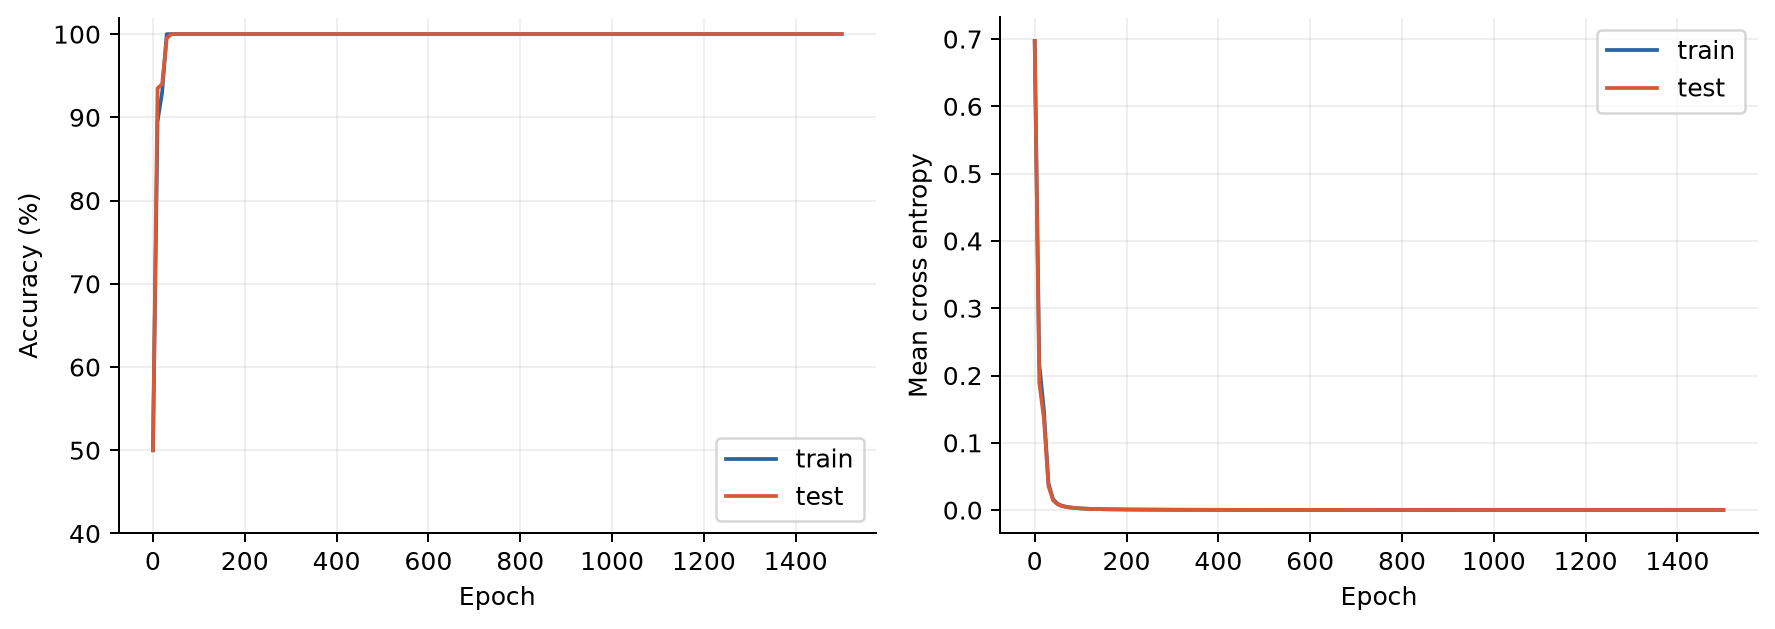

| Batch | Updates | Train % (42) | Test % (42) | Test % mean +/- SD | Seconds mean +/- SD |
| --- | --- | --- | --- | --- | --- |
| 1 | 1200000 | 100.00 | 100.00 | 100.00 +/- 0.00 | 44.29 +/- 0.20 |
| 16 | 75000 | 89.12 | 90.00 | 96.67 +/- 5.77 | 3.66 +/- 0.07 |
| 32 | 37500 | 89.25 | 90.00 | 96.67 +/- 5.77 | 1.97 +/- 0.02 |
| 128 | 10500 | 89.00 | 90.50 | 89.00 +/- 3.50 | 0.76 +/- 0.00 |
| 800 | 1500 | 86.12 | 89.00 | 88.33 +/- 3.06 | 0.36 +/- 0.01 |

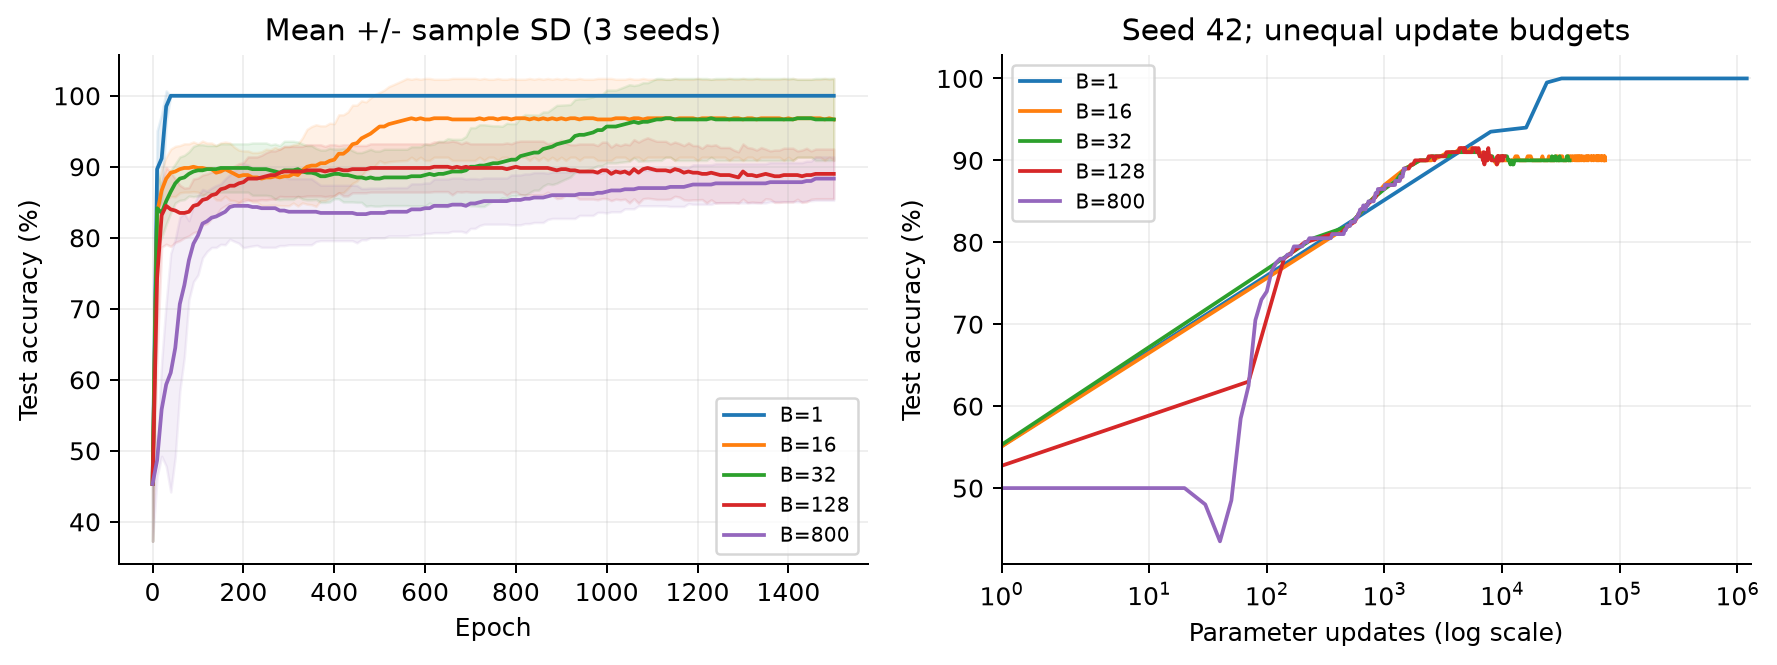

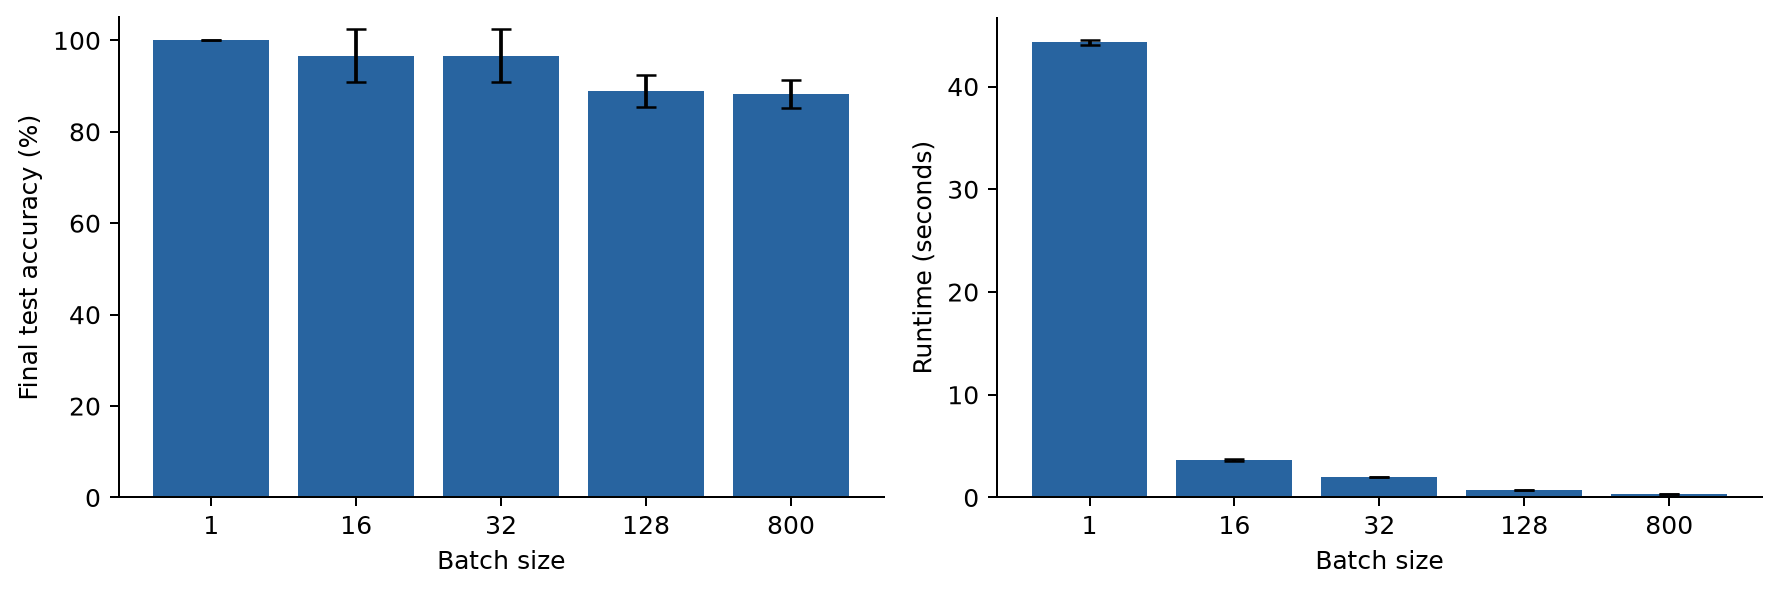

In [6]:
sgd = next(r for r in mlp if r["seed"] == 42 and r["batch_size"] == 1)
print("SGD final metrics:", sgd["history"][-1])
print("Confusion matrix (rows=true, columns=predicted):", sgd["test_confusion_matrix"])
figure("part3_sgd.png")
rows = []
for size in metadata["batch_sizes"]:
    group = [r["history"][-1] for r in mlp if r["batch_size"] == size]
    a = [h["test_accuracy"] for h in group]
    t = [h["elapsed_seconds"] for h in group]
    rows.append([size, group[0]["updates"], format(group[0]["train_accuracy"], ".2f"),
                 format(group[0]["test_accuracy"], ".2f"), f"{np.mean(a):.2f} +/- {np.std(a,ddof=1):.2f}",
                 f"{np.mean(t):.2f} +/- {np.std(t,ddof=1):.2f}"])
table(["Batch", "Updates", "Train % (42)", "Test % (42)", "Test % mean +/- SD", "Seconds mean +/- SD"], rows)
figure("batch_comparison.png")
figure("batch_summary.png")

1500轮意味着每个训练样本被使用1500次，但更新次数不同：SGD为1,200,000次，全批量为1,500次，batch=128为10,500次（每轮7次）。因此这里比较的是相同数据遍历次数，并非相同更新预算。右侧更新次数图展示这一差异，不是额外的等预算实验。

小批次可能在epoch轴上更快提高准确率，但本实现逐批执行NumPy，SGD的Python循环开销很大。耗时包括周期评估，不包含画图和文件保存；它受运行环境影响。每10轮评估的曲线也会隐藏逐样本更新之间的短时波动。三种子只能给出有限的稳定性证据。

## 正确性验证与结论

验证数据数量、可复现性、感知机整批更新、不可分样本的轮数限制、Softmax稳定性与导数、ReLU、多层网络数值梯度、batch尾部处理、以及测试集不会影响训练参数。

In [7]:
import subprocess, sys
check = subprocess.run([sys.executable, "-B", "-m", "unittest", "discover", "-s", "tests", "-v"],
                       cwd=ROOT, capture_output=True, text=True)
print(check.stdout + check.stderr)
assert check.returncode == 0


Maximum absolute network gradient error: 7.637e-11
test_batch_modes_remainder_and_no_test_leakage (test_models.ModelTests.test_batch_modes_remainder_and_no_test_leakage) ... ok
test_full_network_numerical_gradients (test_models.ModelTests.test_full_network_numerical_gradients) ... ok
test_gaussian_split_and_reproducibility (test_models.ModelTests.test_gaussian_split_and_reproducibility) ... ok
test_moons_split (test_models.ModelTests.test_moons_split) ... ok
test_perceptron_convergence_and_epoch_limit (test_models.ModelTests.test_perceptron_convergence_and_epoch_limit) ... ok
test_perceptron_one_batch_update (test_models.ModelTests.test_perceptron_one_batch_update) ... ok
test_relu (test_models.ModelTests.test_relu) ... ok
test_softmax_stability_and_jacobian (test_models.ModelTests.test_softmax_stability_and_jacobian) ... ok

----------------------------------------------------------------------
Ran 8 tests in 0.116s

OK



本实验验证了单个感知机的线性边界限制，以及MLP对双月非线性结构的表示能力。优化结果同时依赖batch size、更新次数、初始化和计算成本。所有最终指标均取预先固定的最后一轮；测试曲线用于作业展示，不用于选择模型。

依据：课程 Assignment_1.pdf；配套感知机教程与代码模板。参考报告仅用于组织结构，本 Notebook 的数值、图表和分析来自本次代码运行。